<a href="https://colab.research.google.com/github/leenoyoon/4th-project/blob/main/NLP_data_preprocessing.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import os
import re
import glob
import pickle
import random
import numpy as np
import matplotlib.pyplot as plt
from collections import Counter
from sklearn.model_selection import train_test_split
from google.colab import drive

drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
zip_path = "/content/drive/MyDrive/SSAC-UNPC.zip"
extract_path = "/content/data/"

if not os.path.exists(zip_path):
    print("Zip file not found")
else:
    if not os.path.exists(extract_path):
        os.makedirs(extract_path)

    os.system(f'unzip -q "{zip_path}" -d "{extract_path}"')
    print("Dataset extracted successfully.")

Dataset extracted successfully.


In [ ]:
PUNCTUATION_MAP = {'NONE': 0, '،': 1, '.': 2, '؟': 3, '!': 4, ':': 5, '؛': 6}
IDX2PUNCT = {v: k for k, v in PUNCTUATION_MAP.items()}
TARGET_CHARS = set(['،', '.', '؟', '!', ':', '؛'])

def clean_text(text):
    text = re.sub(r',', '،', text)
    text = re.sub(r'\?', '؟', text)
    text = re.sub(r';', '؛', text)
    return text

def extract_sentences_and_labels(text):
    sentences = []
    labels = []
    lines = text.split('\n')
    for line in lines:
        line = clean_text(line.strip())
        if not line: continue

        words = line.split()
        line_words = []
        line_labels = []

        for token in words:
            current_label = 0
            current_word = token

            while len(current_word) > 0 and current_word[-1] in TARGET_CHARS:
                current_label = PUNCTUATION_MAP[current_word[-1]]
                current_word = current_word[:-1]

            if current_word:
                line_words.append(current_word)
                line_labels.append(current_label)

        if line_words:
            sentences.append(line_words)
            labels.append(line_labels)

    return sentences, labels

In [ ]:
files = glob.glob(f"{extract_path}/**/*.txt", recursive=True)

all_X = []
all_Y = []

if len(files) > 0:
    random.seed(42)
    random.shuffle(files)
    selected_files = files[:20]

    for i, file_path in enumerate(selected_files):
        try:
            with open(file_path, 'r', encoding='utf-8') as f:
                content = f.read()
                sents, labs = extract_sentences_and_labels(content)
                all_X.extend(sents)
                all_Y.extend(labs)
        except Exception as e:
            print(f"Error reading {file_path}: {e}")

In [ ]:
if len(all_X) > 0:
    vocab = {'<PAD>': 0, '<UNK>': 1}
    word_count = 2

    for sent in all_X:
        for word in sent:
            if word not in vocab:
                vocab[word] = word_count
                word_count += 1

    print(f"Vocabulary size {len(vocab)}")

    X_numerical = [[vocab.get(w, 1) for w in sent] for sent in all_X]
    Y_numerical = all_Y

Vocabulary size 880487


Data saved to: /content/drive/MyDrive/final_processed_data.pkl


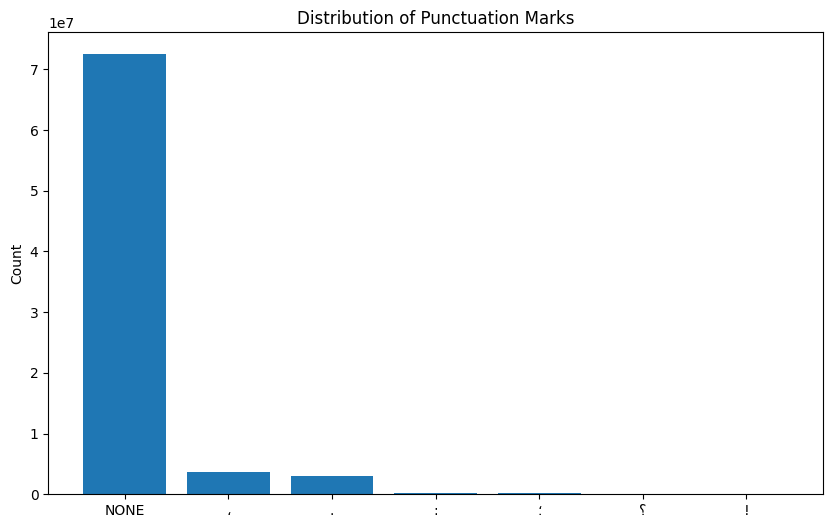

In [ ]:
if len(all_X) > 0:
    X_train, X_temp, y_train, y_temp = train_test_split(X_numerical, Y_numerical, test_size=0.2, random_state=42)
    X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42)

    data_package = {
        "vocab": vocab,
        "X_train": X_train, "y_train": y_train,
        "X_val": X_val, "y_val": y_val,
        "X_test": X_test, "y_test": y_test,
        "idx2punct": IDX2PUNCT
    }

    save_path = '/content/drive/MyDrive/final_processed_data.pkl'
    with open(save_path, 'wb') as f:
        pickle.dump(data_package, f)

    print(f"Data saved to: {save_path}")

    all_tags = [t for s in all_Y for t in s]
    counts = Counter(all_tags)

    plt.figure(figsize=(10, 6))
    plt.bar([IDX2PUNCT[k] for k in counts.keys()], counts.values())
    plt.title("Distribution of Punctuation Marks")
    plt.ylabel("Count")
    plt.show()

In [ ]:
import pickle
import random
import os

file_path = '/content/drive/MyDrive/final_processed_data.pkl'

if os.path.exists(file_path):
    print(f"Loading {file_path}...")

    with open(file_path, 'rb') as f:
        data = pickle.load(f)

    vocab = data['vocab']
    X_train = data['X_train']
    y_train = data['y_train']

    print(f"Keys found: {list(data.keys())}")
    print(f"Vocab size: {len(vocab)}")
    print(f"Train size: {len(X_train)}")

    is_aligned = True
    for i in range(len(X_train)):
        if len(X_train[i]) != len(y_train[i]):
            print(f"Shape mismatch at index {i}: X={len(X_train[i])}, y={len(y_train[i])}")
            is_aligned = False
            break

    if is_aligned:
        print("Data alignment check: PASS")

    idx2word = {v: k for k, v in vocab.items()}
    idx2punct = data.get('idx2punct', {0: '', 1: '،', 2: '.', 3: '؟', 4: '!', 5: ':', 6: '؛'})

    idx = random.randint(0, len(X_train)-1)
    print(f"\nSample at index {idx}:")

    sent_x = X_train[idx]
    sent_y = y_train[idx]

    reconstructed = []
    for w_id, l_id in zip(sent_x, sent_y):
        word = idx2word.get(w_id, '<UNK>')
        label = idx2punct.get(l_id, '')

        if l_id != 0:
            print(f"{word} \t-> {label}")
            reconstructed.append(word + str(label))
        else:
            reconstructed.append(word)

    print("\nFull sentence:")
    print(" ".join(reconstructed))

else:
    print("File not found.")

Loading /content/drive/MyDrive/final_processed_data.pkl...
Keys found: ['vocab', 'X_train', 'y_train', 'X_val', 'y_val', 'X_test', 'y_test', 'idx2punct']
Vocab size: 880487
Train size: 2399946
Data alignment check: PASS

Sample at index 723718:
استراليا 	-> ،
مبكر 	-> .

Full sentence:
ويرمي البرنامج الوطني لاكتشاف سرطان الثدي في استراليا، الى تحقيق انخفاضات كبيرة في عدد الوفيات والحالات المرضية لسرطان الثدي من خلال اكتشاف المرض في وقت مبكر.
